### Objective:
* load stim (boundary + target timepoints)
* load behavior
*   

In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os, glob

### 1. story stimuli

In [2]:
all_stims = pd.read_csv('../data/all_stims.csv')

# all_stims['loc_boundary'] = diff(all_stims['locationEvent'])
all_stims['loc_boundary'] = all_stims['locationEvent'].diff().fillna(0)
all_stims['soc_boundary'] = all_stims['socialEvent'].diff().fillna(0)
all_stims.head(10)

,story,sentence_number,storyText,locationEvent,socialEvent,locationAnswer,socialAnswer,presentationTime,loc_boundary,soc_boundary
0,11,1,"A bell chimed as the door swung open, and Sadi...",1,1,0,0,0.00,0.0,0.0
1,11,2,Thomas had been thinking about breaking up wit...,1,1,0,1,12.05,0.0,0.0
2,11,3,The restaurant he had chosen to meet at was re...,1,1,1,0,16.53,0.0,0.0
3,11,4,There was black and white checkerboard tiling ...,1,1,0,0,21.53,0.0,0.0
4,11,5,"Thomas stood up and gave Sadie a side hug, ask...",1,1,0,0,30.62,0.0,0.0
5,11,6,"She clung onto him, “It was okay- I missed you...",1,1,0,0,36.38,0.0,0.0
6,11,7,He looked away and addressed the hostess comin...,1,1,0,0,40.97,0.0,0.0
7,11,8,She shrugged and after loudly popping her bubb...,1,1,0,0,47.51,0.0,0.0
8,11,9,The hostess seated them at a booth in the back...,2,1,0,0,53.29,1.0,0.0
9,11,10,Sadie slipped into the cushioned seat and grab...,2,1,0,0,57.61,0.0,0.0


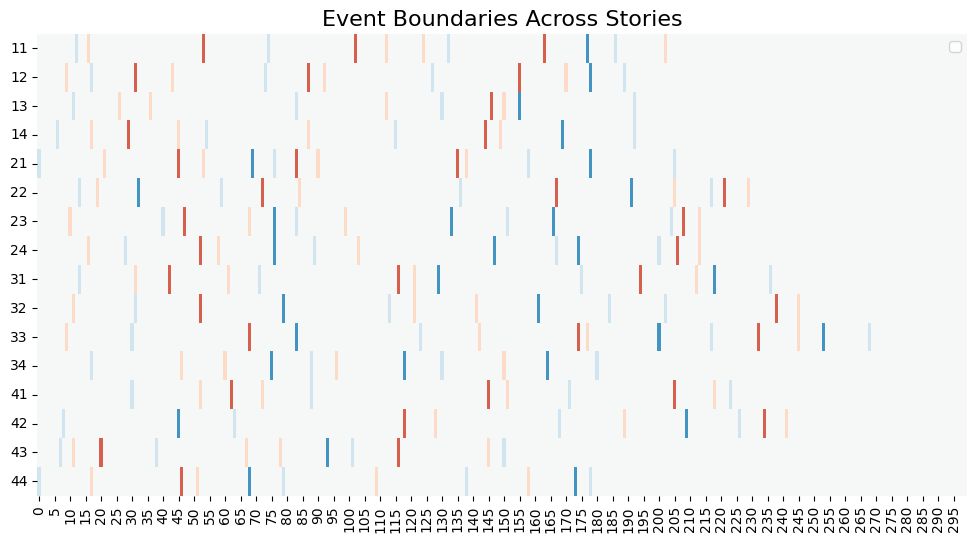

In [16]:
# story_dict: keys = unique vals in story col, vals = arr of len 300
story_dict = {story: np.zeros(300) for story in all_stims['story'].unique()}
story_dict

# populate per story/key's list/value with values for boundaries and answer for both types of scripts
for story in story_dict.keys():
    # grab data for current story
    story_rows = all_stims[all_stims['story'] == story]

    # get presentationTime for rows where loc_boundary == 1 and story == current story
    loc_boundary_times = story_rows[story_rows['loc_boundary'] == 1]['presentationTime'].values
    soc_boundary_times = story_rows[story_rows['soc_boundary'] == 1]['presentationTime'].values
    story_dict[story][loc_boundary_times.astype(int)] = -3
    story_dict[story][soc_boundary_times.astype(int)] = 3

    # similarly for locationAnswer and socialAnswer
    loc_answer_times = story_rows[story_rows['locationAnswer'] != 0]['presentationTime'].values
    soc_answer_times = story_rows[story_rows['socialAnswer'] != 0]['presentationTime'].values
    story_dict[story][loc_answer_times.astype(int)] = -1
    story_dict[story][soc_answer_times.astype(int)] = 1

# stack all list vertically
story_array = np.stack(list(story_dict.values()), axis=0)
story_array.shape

plt.figure(figsize=(12, 6))
plt.title('Event Boundaries Across Stories', fontsize=16)
plt.xlabel('Time (s)')
plt.ylabel('Story')
plt.legend(['Location Boundary', 'Social Boundary', 'Location Answer', 'Social Answer'], loc='upper right')
sns.heatmap(story_array, cmap='RdBu', cbar=False, vmin=-5, vmax=5)
plt.yticks(ticks=np.arange(len(story_dict)) + 0.5, labels=story_dict.keys(), rotation=0)
plt.show()

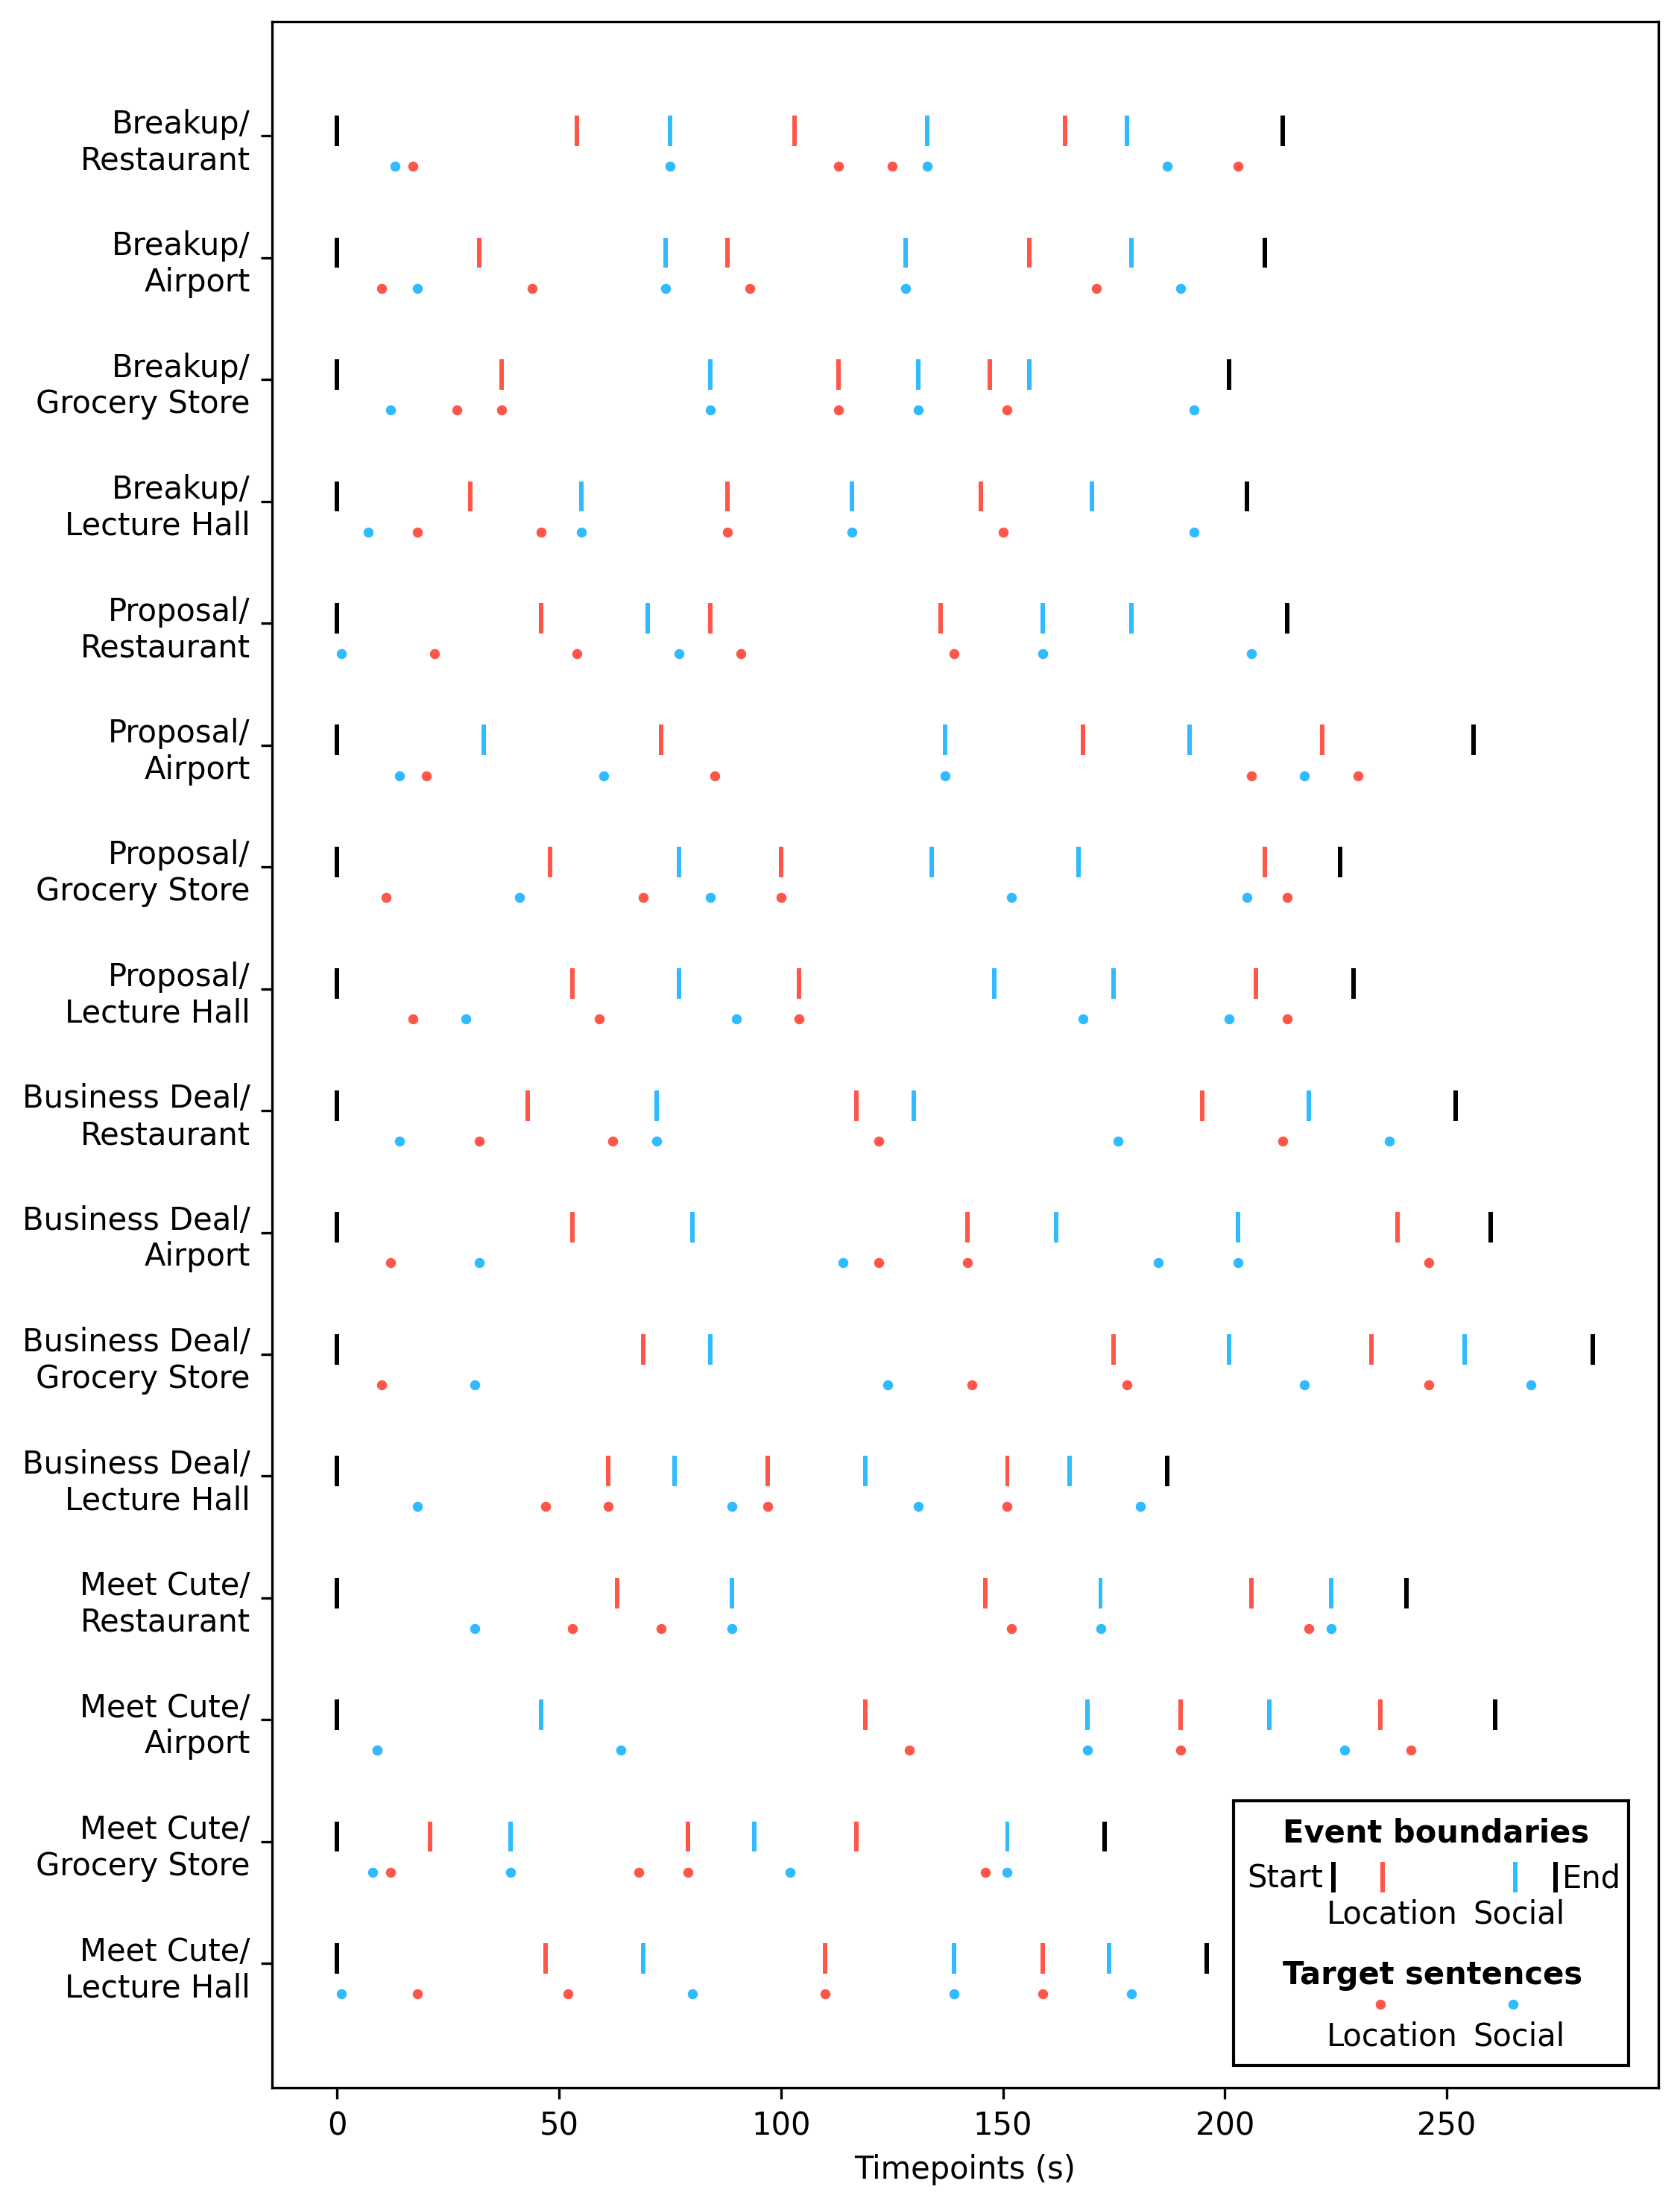

In [20]:
# display better fig from paper's code: ../results/figs/boundaries_and_targets.png
from IPython.display import Image
Image(filename='../results/figs/boundaries_and_targets.png')

### 2. behavior

In [26]:
online_boundaries = pd.read_csv('../data/behavior/online_boundary_data.csv')
print(online_boundaries.shape)
online_boundaries.head()

(308, 4)


,prolific_id,story_presses,story,p_type
0,5cdeaeb3557fbd00018a2c59,9191191911911111191191199111,44,np
1,5ea07ccfcc5aed04bc7e4148,91119111111111911191111191111111111911911,11,np
2,5d0e2a06facd7500197a46e3,119119111119191919919111119191,21,loc
3,5e84ab6c1c387d0424a1b662,9911911919111199119911119119111,12,soc
4,5c1cfb57e2d9150001b5975b,911991911199191919911111191911119999919,23,loc


In [46]:
online_memory = pd.read_csv('../data/behavior/online_SA.csv')
print(online_memory.shape)
online_memory.head(6)

(750, 5)


,sub,priming,qt,avg,story
0,0,np,avg_loc,0.75,23
1,0,np,avg_soc,0.75,23
2,1,np,avg_loc,0.75,23
3,1,np,avg_soc,0.90,23
4,2,np,avg_loc,1.75,23
5,2,np,avg_soc,2.05,23


In [45]:
fMRI_memory = pd.read_csv('../data/behavior/fMRI_SA.csv')
print(fMRI_memory.shape)
# avg/group by sub, priming & qt; drop story col
fMRI_memory = fMRI_memory.groupby(['sub', 'priming', 'qt']).mean().reset_index().drop(columns=['story'])
print(fMRI_memory.shape)
fMRI_memory.head(6)

(864, 5)
(216, 4)


,sub,priming,qt,avg
0,sub-01,loc,avg_loc,1.6250
1,sub-01,loc,avg_soc,0.7500
2,sub-01,np,avg_loc,0.5625
3,sub-01,np,avg_soc,1.0625
4,sub-01,soc,avg_loc,0.3125
5,sub-01,soc,avg_soc,1.6875
